In [1]:
# Source - https://stackoverflow.com/a/5399339
# Posted by pv., modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-26, License - CC BY-SA 4.0

%load_ext autoreload
%autoreload 2


In [2]:
import os
import sys
import yaml
import pickle
from pathlib import Path
from typing import Any, Dict

# Disable XLA preallocation to avoid hogging GPU memory
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm
from absl import flags

import jax
import jax.numpy as jnp
from jax import config as jax_config
import optax
import haiku as hk
from flax.training.early_stopping import EarlyStopping
import wandb

import jax_cosmo as jc
from jaxpm.nn import CNN, NeuralSplineFourierFilter
from jaxpm.painting import compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.pm import get_delta

/cosmos_storage/home/diegovillalba/JaxPM/.venv/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [3]:
# import jax, jax.numpy as jnp
# import numpy as np

# # Debug: desactiva JIT temporalmente
# jax.config.update("jax_disable_jit", True)

# # (Opcional) Asegura float32 por default en tu notebook (no siempre necesario)
# jax.config.update("jax_enable_x64", False)

# print("JIT disabled =", jax.config.jax_disable_jit)
# print("x64 enabled =", jax.config.jax_enable_x64)

In [4]:
from pm2nbody.read_data import load_datasets
from pm2nbody.loss import (
    get_frozen_potential_loss,
    get_potential_loss,
    get_position_loss,
    get_mse_pos,
)

In [5]:

# --- Global Configurations ---
jax_config.update("jax_enable_x64", False)

mpl.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "serif",
    }
)
mpl.rcParams["figure.dpi"] = 300
plt.style.use("default")

DEFAULT_DATA_DIR = Path("/cosmos_storage/home/diegovillalba/JaxPM/data/")
DEFAULT_MODEL_DIR = Path("/cosmos_storage/home/diegovillalba/JaxPM/models/")



In [6]:
# FLAGS = flags.FLAGS
# FLAGS(sys.argv)
cfg = {
        "data": {
            "mesh_lr": 128,
            "mesh_hr": 256,
            "n_train_sims": 1,
            "n_val_sims": 1,
            "n_test_sims": 1,
            "snapshots": None,
            "box_size": 256.0,
            "n_snapshots": 50,
            "n_particles": 128,
        },
        "correction_model": {
            "type": "cnn",
            "channels_hidden_dim": 16,
            "n_convolutions": 3,
            "n_fully_connected": 2,
            "input_dim": 1,
            "kernel_size": 3,
            "pad_periodic": True,
            "embed_globals": False,
            "n_globals_embedding": 1,
            "globals_embedding_dim": 64,
            "global_conditioning": "add",
            "use_attention_interpolation": False,
            "add_particle_velocities": True,
            "n_knots": 16,
            "latent_size": 64,
        },
        "training": {
            "seed": 0,
            "n_steps": 100,
            "batch_size": 1,
            "patience": 20,
            "checkpoint_every": 5,
            "sample_snapshots": True,
            "loss": "mse_positions",
            "weight_snapshots": True,
            "lambda_pos": 1.0,
            "lambda_velocity": 1.0,
            "lambda_density": 0.0,
            "lambda_pk": 0.0,
            "lambda_cross_corr": 0.0,
            "log_pos": False,
            "fractional_mse": False,
            "weight_decay": 1e-4,
            "max_idx": 49,
            "schedule": {
                "type": "cosine",
                "initial_lr": 0.0,
                "peak_value": 3e-4,
                "warmup_steps": 50,
                "n_steps": 20_000,
                "factor": 0.5,
                "patience": 5,
                "min_lr": 1e-6,
            },
        },
        "wandb": {
            "project": "pm2nbody",
        },
    }


In [7]:
from types import SimpleNamespace

def dict_to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{
            k: dict_to_namespace(v) for k, v in d.items()
        })
    return d

config = dict_to_namespace(cfg)

In [8]:
config.correction_model.type

'cnn'

In [9]:
import sys
sys.path.append("/cosmos_storage/home/diegovillalba/JaxPM/pm2nbody/")
from train_refactored import build_network
from train_refactored import build_dataloader
from train_refactored import initialize_network
from train_refactored import build_loss_fn
from train_refactored import build_schedule
from train_refactored import build_optimizer
from train_refactored import print_initial_lr_loss
from train_refactored import plot_eval

In [10]:
neural_net = build_network(config.correction_model)

2026-03-05 00:04:32,930 - INFO - Building correction model of type: cnn
2026-03-05 00:04:32,931 - INFO - Using CNN-based correction model.


In [11]:
cosmology, scale_factors, train_data, val_data, test_data = build_dataloader(
        config.data, data_dir=DEFAULT_DATA_DIR
    )

2026-03-05 00:04:34,795 - INFO - Cosmology created


INFO:2026-03-05 00:04:35,063:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-03-05 00:04:35,063 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-03-05 00:04:35,311 - INFO - Loading datasets with n_train_sims=1, n_val_sims=1, n_test_sims=1, mesh_hr=256, mesh_lr=128, box_size=256.0, snapshots=None
2026-03-05 00:04:35,355 - INFO - Loading data for simulation index 1 with mesh_hr=256, mesh_lr=128, box_size=256.0, snapshots=None
2026-03-05 00:04:43,153 - INFO - Loading data for simulation index 0 with mesh_hr=256, mesh_lr=128, box_size=256.0, snapshots=None
2026-03-05 00:04:50,570 - INFO - Loading data for simulation index 2 with mesh_hr=256, mesh_lr=128, box_size=256.0, snapshots=None
2026-03-05 00:04:57,981 - INFO - Datasets Created: Train (1), Val (1), Test (1)
2

Train example keys: (50, 128, 128, 128), (50, 2097152, 3), (50, 2097152, 3)


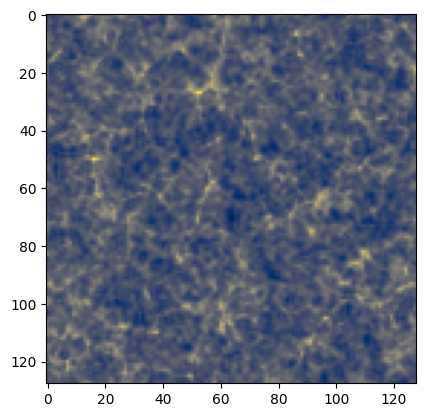

In [12]:
train_example = train_data[0]
print(f"Train example keys: {train_example['lr'].density_grid.shape}, {train_example['lr'].positions.shape}, {train_example['lr'].velocities.shape}")
plt.imshow(train_example["lr"].density_grid[0, :, :, 0],cmap='cividis')

In [13]:
print(vars(train_example["lr"]).keys())

dict_keys(['mesh', 'positions', 'velocities', 'potential', 'potential_grid', 'density_grid', 'grid', '_scaled_to_mesh'])


In [16]:
loss_fn = build_loss_fn(
        config.training, neural_net, cosmology,
    correction_type=config.correction_model.type,
    mesh_lr=train_data[0]["lr"].mesh,
)

print("scale_factors:", scale_factors.shape, scale_factors.dtype)
print("mesh_lr:", train_data[0]["lr"].mesh, "mesh_hr:", train_data[0]["hr"].mesh)

2026-03-05 00:05:22,945 - INFO - Building loss function for training with loss type: mse_positions
2026-03-05 00:05:22,946 - INFO - Correction model type for loss function: cnn
2026-03-05 00:05:22,946 - INFO - Using MSE loss on positions with vmap over snapshots.
2026-03-05 00:05:22,947 - INFO - JIT compiling position loss function (mesh-units + periodic minimal-image).


scale_factors: (50,) float32
mesh_lr: 128 mesh_hr: 128


In [17]:
batch_cpu = next(train_data.iterator)        # objetos del dataset (CPU)
dev = jax.devices()[0]
batch = train_data.move_to_device(batch_cpu, device=dev)  # batch para correr (GPU/CPU)

lr = batch["lr"]
hr = batch["hr"]

print("Devices:", lr.positions.device, hr.positions.device)
print("Shapes:",
      "lr.pos", lr.positions.shape,
      "lr.vel", lr.velocities.shape,
      "hr.pos", hr.positions.shape,
      "hr.vel", hr.velocities.shape)
print("mesh_lr in batch:", lr.mesh, "mesh_hr in batch:", hr.mesh)

Devices: cuda:0 cuda:0
Shapes: lr.pos (50, 2097152, 3) lr.vel (50, 2097152, 3) hr.pos (50, 2097152, 3) hr.vel (50, 2097152, 3)
mesh_lr in batch: 128 mesh_hr in batch: 128


In [18]:
mesh_lr = lr.mesh
mesh_hr = hr.mesh

# max típico de pos
mx_lr = float(jnp.max(lr.positions[49]))
mx_hr = float(jnp.max(hr.positions[49]))

print("max lr.pos[t0] =", mx_lr)
print("max hr.pos[t0] =", mx_hr)
print("mesh_lr =", mesh_lr, "mesh_hr =", mesh_hr)

# Heurística:
# - si mx_lr ~ mesh_lr y mx_hr ~ mesh_lr => consistente (ambos mesh_lr units)
# - si mx_lr ~ 1 y mx_hr ~ 1 => consistente (ambos unit box) PERO tu loss debe esperar eso
# - si mx_lr ~ mesh_lr y mx_hr ~ mesh_hr => inconsistente y rompe % n_mesh

max lr.pos[t0] = 136.75303649902344
max hr.pos[t0] = 137.05580139160156
mesh_lr = 128 mesh_hr = 128


In [19]:
params = initialize_network(
        train_data[0], neural_net=neural_net, model_type=config.correction_model.type
    )

2026-03-05 00:05:47,075 - INFO - Initializing network parameters with seed 42 for model type cnn


2026-03-05 00:05:47,723 - INFO - Initializing only the CNN correction model parameters.
/cosmos_storage/home/diegovillalba/JaxPM/.venv/lib/python3.11/site-packages/haiku/_src/base.py:664: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  param = init(shape, dtype)
/cosmos_storage/home/diegovillalba/JaxPM/.venv/lib/python3.11/site-packages/haiku/_src/base.py:664: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  param = init(shape, dtype)


In [20]:
schedule = build_schedule(config.training.schedule)
optimizer, opt_state = build_optimizer(
        config.training, params=params, schedule=schedule
    )

In [21]:
print_initial_lr_loss(val_data)

early_stop = EarlyStopping(patience=config.training.patience)
best_params = params
best_loss = float("inf")

2026-03-05 00:05:59,475 - INFO - Calculating initial loss on validation set with untrained model...


2026-03-05 00:06:00,818 - INFO - Positions MSE  = 0.14771
2026-03-05 00:06:00,820 - INFO - Velocities MSE = 0.20441
2026-03-05 00:06:00,820 - INFO - Potential MSE  = 0.70997


In [ ]:
import jax
import jax.numpy as jnp

# 1) Ejecuta la loss para obtener aux (pos_pm)
out = loss_fn(params, batch, scale_factors)

if isinstance(out, tuple):
    loss_val, aux = out
else:
    loss_val, aux = out, None

print("loss_fn output type:", type(out))
print("loss =", float(loss_val))
print("aux is None?", aux is None)

# 2) Si no hay aux, no podemos inspeccionar pos_pm
if aux is None:
    raise RuntimeError(
        "Tu loss_fn no devolvió aux. Para mse_positions, get_position_loss debe retornar (loss, pos_pm)."
    )

mesh_lr = batch["lr"].mesh
n = jnp.asarray(mesh_lr, dtype=jnp.float32)

pos_lr0 = batch["lr"].positions[0]   # MESH units (no box)
pos_hr0 = batch["hr"].positions[0]   # MESH units (no box)
pos_pm0 = aux[0]                     # MESH units

def quick_stats(name, x):
    x = jnp.asarray(x)
    return (name,
            float(jnp.min(x)), float(jnp.max(x)),
            float(jnp.mean(x)), float(jnp.std(x)),
            bool(jnp.isnan(x).any()), bool(jnp.isinf(x).any()))

print("mesh_lr =", mesh_lr)
print(quick_stats("pos_lr[t0] (mesh)", pos_lr0))
print(quick_stats("pos_hr[t0] (mesh)", pos_hr0))
print(quick_stats("pos_pm[t0] (mesh)", pos_pm0))

# Periodic minimal-image error in mesh units
pos_pm0w = jnp.mod(pos_pm0, n)
pos_hr0w = jnp.mod(pos_hr0, n)

d = pos_pm0w - pos_hr0w
d = d - n * jnp.round(d / n)     # [-n/2, n/2)

mse_mesh = jnp.mean(jnp.sum(d*d, axis=-1))
mse_mesh_norm = mse_mesh / (n*n)  # comparable across meshes

print("MSE mesh units =", float(mse_mesh))
print("MSE mesh units normalized (÷n^2) =", float(mse_mesh_norm))

# Sanity: mod in mesh should not change prediction much
pos_pml = aux[-1]
delta_mod_mesh = jnp.mean(jnp.abs(jnp.mod(pos_pml, n) - pos_pml))
print("mean |mod(pos_pm,mesh)-pos_pm| =", float(delta_mod_mesh))



loss_fn output type: <class 'tuple'>
loss = 4.483178781811148e-05
aux is None? False
mesh_lr = 128
('pos_lr[t0] (mesh)', -1.1428805589675903, 128.1901092529297, 63.5, 36.938568115234375, False, False)
('pos_hr[t0] (mesh)', -1.17722487449646, 128.1855010986328, 63.5, 36.938270568847656, False, False)
('pos_pm[t0] (mesh)', 1.3302339539222885e-05, 127.99998474121094, 63.946006774902344, 36.93928909301758, False, False)
MSE mesh units = 0.007380479946732521
MSE mesh units normalized (÷n^2) = 4.504687467488111e-07
mean |mod(pos_pm,mesh)-pos_pm| = 2.0345052689663135e-05


In [28]:
# ==========================================
# CELL 1: SETUP & EXTRACCIÓN DEL PRIMER LOTE
# ==========================================

# 1. Definimos el wrapper para que JAX pueda derivar respecto a 'params'
def train_loss_fn(p, batch, sf):
    out = loss_fn(params=p, dataset=batch, scale_factors=sf)
    return out[0] if isinstance(out, tuple) else out

# 2. Simulamos la selección dinámica del snapshot
# rng = jax.random.PRNGKey(42) # Semilla fija para debug
# if config.training.sample_snapshots:
#     rng, _ = jax.random.split(rng)
#     # max_idx = jax.random.randint(
#     #     rng, minval=10, maxval=len(scale_factors), shape=(1,)
#     # )[0]
#     max_idx = jnp.asarray(len(scale_factors)-1, dtype=jnp.int32)
# else:
#     max_idx = None

max_idx = jnp.asarray(len(scale_factors)-1, dtype=jnp.int32)
# 3. Extraemos UN SOLO batch manualmente
batch = next(train_data.iterator)
batch = train_data.move_to_device(batch, device=jax.devices()[0])

print(f"Max Index seleccionado: {max_idx}")
print(f"Shape de Posiciones LR: {batch['lr'].positions.shape}")
print(f"Shape de Posiciones HR (Target): {batch['hr'].positions.shape}")

Max Index seleccionado: 49
Shape de Posiciones LR: (50, 2097152, 3)
Shape de Posiciones HR (Target): (50, 2097152, 3)


In [24]:
import subprocess

def gpu_mem_mib():
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,nounits,noheader"]
    ).decode().strip().splitlines()
    # si hay varias GPUs, toma la 0
    used, total = out[0].split(",")
    return int(used), int(total)

def print_gpu_mem(tag=""):
    used, total = gpu_mem_mib()
    print(f"[GPU mem] {tag}: {used} MiB / {total} MiB")
import numpy as np
import jax
import jax.numpy as jnp
import jax.tree_util as tree

def pytree_nbytes(pytree):
    leaves = tree.tree_leaves(pytree)
    n = 0
    for x in leaves:
        # JAX array / numpy array / python scalar
        if hasattr(x, "dtype") and hasattr(x, "shape"):
            n += np.prod(x.shape) * np.dtype(x.dtype).itemsize
    return int(n)

def pretty_bytes(n):
    for unit in ["B","KiB","MiB","GiB","TiB"]:
        if n < 1024:
            return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} PiB"

def print_pytree_bytes(name, pytree):
    print(f"[{name}] approx bytes = {pretty_bytes(pytree_nbytes(pytree))}")

In [25]:
import numpy as np

def arr_bytes(x):
    return int(np.prod(x.shape)) * np.dtype(x.dtype).itemsize

def resolution_bytes(rd):
    total = 0
    total += arr_bytes(rd.positions)
    total += arr_bytes(rd.velocities)
    total += arr_bytes(rd.potential)
    if getattr(rd, "potential_grid", None) is not None:
        total += arr_bytes(rd.potential_grid)
    if getattr(rd, "density_grid", None) is not None:
        total += arr_bytes(rd.density_grid)
    if getattr(rd, "grid", None) is not None:
        total += arr_bytes(rd.grid)
    return total

def print_batch_bytes(batch):
    lr = batch["lr"]; hr = batch["hr"]
    print("LR batch bytes:", lr.positions.shape, lr.positions.dtype, resolution_bytes(lr)/1024**3, "GiB")
    print("HR batch bytes:", hr.positions.shape, hr.positions.dtype, resolution_bytes(hr)/1024**3, "GiB")

print_batch_bytes(batch)

LR batch bytes: (50, 2097152, 3) float32 3.515625 GiB
HR batch bytes: (50, 2097152, 3) float32 2.734375 GiB


In [25]:
os.environ["JAX_LOG_COMPILES"] = "1.0"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"

In [26]:
def info(name, x):
    print(f"{name}: type={type(x)} shape={getattr(x,'shape',None)} ndim={getattr(x,'ndim',None)}")

info("scale_factors", scale_factors)
# info("max_idx", max_idx)

lr = batch["lr"]; hr = batch["hr"]
info("lr.positions", lr.positions)
info("lr.velocities", lr.velocities)
info("hr.positions", hr.positions)
info("hr.velocities", hr.velocities)

# si usas grid en loss
info("lr.potential_grid", lr.potential_grid)
info("lr.density_grid", lr.density_grid)
info("lr.grid", lr.grid)

scale_factors: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50,) ndim=1
lr.positions: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 2097152, 3) ndim=3
lr.velocities: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 2097152, 3) ndim=3
hr.positions: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 2097152, 3) ndim=3
hr.velocities: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 2097152, 3) ndim=3
lr.potential_grid: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 128, 128, 128) ndim=4
lr.density_grid: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 128, 128, 128) ndim=4
lr.grid: type=<class 'NoneType'> shape=None ndim=None


In [29]:
# ==========================================
# CELL 2: FORWARD PASS & GRADIENTES (MEM DEBUG)
# ==========================================

print_gpu_mem("before forward")

print_pytree_bytes("params", params)
print_pytree_bytes("batch", batch)  # ojo: si batch incluye simulación completa, aquí se ve enorme

# Ensure all arrays in batch are on the same device (GPU)
# from jax import device_put
# def move_batch_to_device(batch, device):
#     for res in ['lr', 'hr']:
#         for attr in ['grid', 'positions', 'velocities', 'potential', 'potential_grid', 'density_grid']:
#             if hasattr(batch[res], attr):
#                 arr = getattr(batch[res], attr)
#                 if hasattr(arr, 'device') and arr.device != device:
#                     setattr(batch[res], attr, device_put(arr, device))
#     return batch
print("scale_factors:", type(scale_factors), getattr(scale_factors, "shape", None), scale_factors)
# print("max_idx:", type(max_idx), getattr(max_idx, "shape", None), max_idx)

# batch = move_batch_to_device(batch, jax.devices()[0])

# Forward + grad
train_loss, grads = jax.value_and_grad(train_loss_fn)(params, batch, scale_factors)
# Sync (muy importante)
train_loss.block_until_ready()

print_gpu_mem("after forward+grad")

print(f"Pérdida (Loss) del Batch: {float(train_loss):.5f}")

print_pytree_bytes("grads", grads)

# Opcional: inspeccionar el top-10 grad tensors más grandes
leaves = tree.tree_leaves(grads)
sizes = []
for i, x in enumerate(leaves):
    if hasattr(x, "shape") and hasattr(x, "dtype"):
        sizes.append((i, int(np.prod(x.shape) * np.dtype(x.dtype).itemsize), x.shape, x.dtype))
sizes.sort(key=lambda t: t[1], reverse=True)

print("\nTop 10 grad leaves by size:")
for i, nb, shape, dtype in sizes[:10]:
    print(f"  leaf {i:03d}: {pretty_bytes(nb)}  shape={shape} dtype={dtype}")

# Tu check de norms (con cuidado: linalg.norm en arrays grandes también aloca)
grad_norms = tree.tree_map(lambda x: jnp.linalg.norm(x).block_until_ready() if hasattr(x, "shape") else x, grads)

print("\nGrad norms (flattened):")
for norm in tree.tree_leaves(grad_norms)[:20]:
    print(float(norm))

[GPU mem] before forward: 21284 MiB / 97887 MiB
[params] approx bytes = 66.39 KiB
[batch] approx bytes = 6.25 GiB
scale_factors: <class 'jaxlib._jax.ArrayImpl'> (50,) [0.1        0.11836734 0.1367347  0.15510204 0.1734694  0.19183673
 0.21020408 0.22857143 0.24693878 0.26530612 0.28367347 0.30204082
 0.32040817 0.33877552 0.35714287 0.37551022 0.39387757 0.4122449
 0.43061224 0.4489796  0.46734694 0.4857143  0.5040816  0.52244896
 0.5408163  0.55918366 0.577551   0.59591836 0.6142857  0.63265306
 0.6510204  0.66938776 0.6877551  0.70612246 0.7244898  0.74285716
 0.7612245  0.77959186 0.7979592  0.81632656 0.83469385 0.8530612
 0.87142855 0.8897959  0.90816325 0.9265306  0.94489795 0.9632653
 0.98163265 1.        ]


E0305 00:11:04.292730  923945 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0305 00:11:04.487568  923945 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[GPU mem] after forward+grad: 37676 MiB / 97887 MiB
Pérdida (Loss) del Batch: 0.00004
[grads] approx bytes = 66.39 KiB

Top 10 grad leaves by size:
  leaf 007: 27.00 KiB  shape=(3, 3, 3, 16, 16) dtype=float32
  leaf 013: 27.00 KiB  shape=(3, 3, 3, 16, 16) dtype=float32
  leaf 001: 3.38 KiB  shape=(3, 3, 3, 2, 16) dtype=float32
  leaf 019: 2.19 KiB  shape=(35, 16) dtype=float32
  leaf 005: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 009: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 011: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 015: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 017: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 021: 1.00 KiB  shape=(16, 16) dtype=float32

Grad norms (flattened):
2.2756304929316684e-07
8.821125447866507e-06
2.3408968274907238e-07
4.6515754803522213e-08
3.114654703040287e-07
1.9679602303313004e-07
3.230052811886708e-07
2.007279545068741e-05
2.0088653229777265e-07
1.0093339852801364e-07
4.2562402313706116e-07
1.4179951790538325e-07
4.811816438632377

In [30]:
# ==========================================
# CELL 3: OPTIMIZER UPDATE (OPTILAX / OPTAX)
# ==========================================

# 1. Calculamos cómo deben cambiar los pesos basándonos en los gradientes
updates, opt_state = optimizer.update(grads, opt_state, params)

# 2. Aplicamos esos cambios a nuestra red neuronal
params = optax.apply_updates(params, updates)

print("¡Pesos actualizados exitosamente!")

# Si tu learning rate usa un schedule dinámico (cosine decay), podemos verlo así:
try:
    current_lr = opt_state.inner_opt_state[1].hyperparams["learning_rate"]
    print(f"Learning Rate actual: {current_lr}")
except AttributeError:
    print("Learning Rate es estático o la estructura del opt_state es diferente.")

¡Pesos actualizados exitosamente!
Learning Rate actual: 0.0


In [29]:
from tqdm.notebook import tqdm

n_debug_steps = 100
pbar_debug = tqdm(range(n_debug_steps), desc="Entrenando mini-bucle (mem-debug)")

print_gpu_mem("start")
print_pytree_bytes("params (static)", params)

# TIP: fija max_idx para ver si el crecimiento es por recompilación
# fixed_max_idx = jnp.asarray(len(scale_factors)-1, dtype=jnp.int32)

for step in pbar_debug:
    # 1) max_idx
    if config.training.sample_snapshots:
        # rng, _ = jax.random.split(rng)
        # max_idx = jax.random.randint(
        #     rng, minval=10, maxval=len(scale_factors), shape=(1,), dtype=jnp.int32
        # )[0]
        max_idx = jnp.asarray(20, dtype=jnp.int32)
    else:
        max_idx = jnp.asarray(len(scale_factors)-1, dtype=jnp.int32)

    # 2) batch
    batch = next(train_data.iterator)

    # Diagnóstico: tamaño del batch en bytes (CPU o GPU)
    if step == 0:
        print_pytree_bytes("batch (before move)", batch)

    batch = train_data.move_to_device(batch, device=jax.devices()[0])

    if step == 0:
        # imprime shapes clave para confirmar si estás moviendo trayectoria completa
        print("LR positions:", batch["lr"].positions.shape, batch["lr"].positions.dtype,
              "device:", batch["lr"].positions.device)
        print("HR positions:", batch["hr"].positions.shape, batch["hr"].positions.dtype,
              "device:", batch["hr"].positions.device)
        if getattr(batch["lr"], "potential_grid", None) is not None:
            print("LR pot_grid:", batch["lr"].potential_grid.shape, batch["lr"].potential_grid.dtype,
                  "device:", batch["lr"].potential_grid.device)
        if getattr(batch["lr"], "density_grid", None) is not None:
            print("LR dens_grid:", batch["lr"].density_grid.shape, batch["lr"].density_grid.dtype,
                  "device:", batch["lr"].density_grid.device)

    # 3) forward+grad (medimos memoria antes y después)
    print_gpu_mem(f"step {step} before fwd")

    train_loss, grads = jax.value_and_grad(train_loss_fn)(params, batch, scale_factors)

    # 🔴 sincroniza para que la medición sea real
    train_loss.block_until_ready()
    print_gpu_mem(f"step {step} after fwd+grad")

    # 4) optim update (también puede alocar)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    # sincroniza una hoja de grads (opcional) para medir post-update
    # (bloquea usando un leaf pequeño o el loss ya sirve)
    train_loss.block_until_ready()
    print_gpu_mem(f"step {step} after update")

    pbar_debug.set_postfix({"Loss": f"{float(train_loss):.5f}", "max_idx": int(max_idx)})

    # 5) chequeo rápido de crecimiento sostenido
    if step == 0:
        print_pytree_bytes("grads (step0)", grads)

    # ✅ evita retener referencias: borra explícitamente
    del grads, updates, batch

    if step > 0 and step % 10 == 0:
        print(f"Step {step} | Loss: {float(train_loss):.5f} | max_idx={int(max_idx)}")

print_gpu_mem("end")
print("¡Mini-entrenamiento completado!")

Entrenando mini-bucle (mem-debug):   0%|          | 0/100 [00:00<?, ?it/s]

[GPU mem] start: 37660 MiB / 97887 MiB
[params (static)] approx bytes = 66.39 KiB
[batch (before move)] approx bytes = 6.25 GiB
LR positions: (50, 2097152, 3) float32 device: cuda:0
HR positions: (50, 2097152, 3) float32 device: cuda:0
LR pot_grid: (50, 128, 128, 128) float32 device: cuda:0
LR dens_grid: (50, 128, 128, 128) float32 device: cuda:0
[GPU mem] step 0 before fwd: 37660 MiB / 97887 MiB


KeyboardInterrupt: 

Validation Loss Media: 0.00004


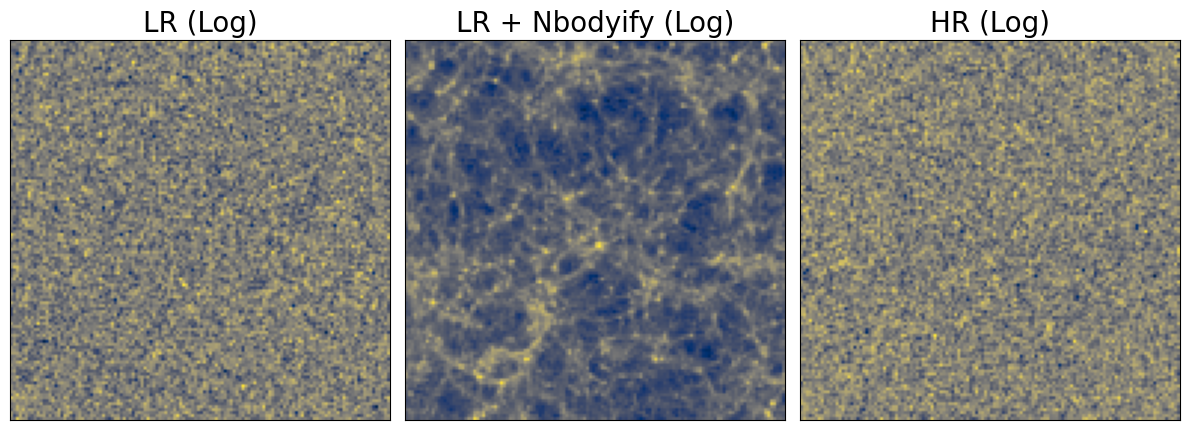

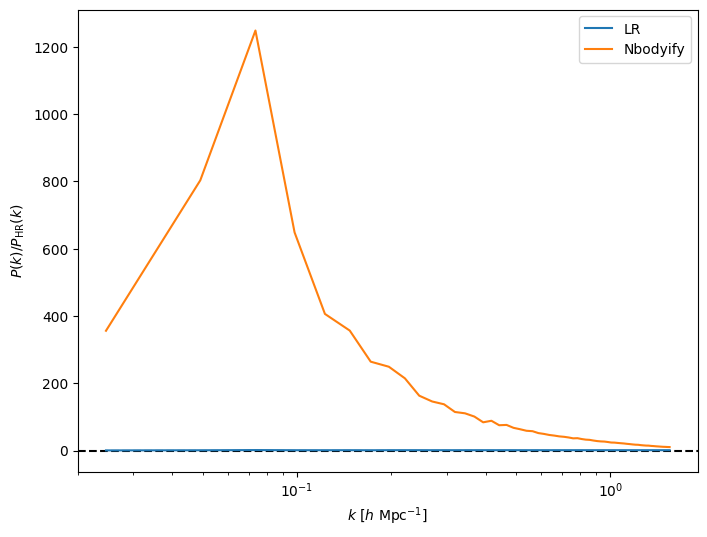

In [31]:
# ==========================================
# CELL 4: EVALUACIÓN / VALIDACIÓN MÚLTIPLE
# ==========================================

val_loss_total = 0.0

# Iteramos sobre todo el conjunto de validación
for val_batch in val_data:
    val_batch = val_data.move_to_device(val_batch, device=jax.devices()[0])
    
    # Nota: Aquí llamamos a loss_fn DIRECTAMENTE, sin value_and_grad
    # vl es el loss, val_pos_pm son las posiciones corregidas que devuelve tu función
    vl, val_pos_pm = loss_fn(params, val_batch, scale_factors)
    val_loss_total += vl

val_loss_mean = val_loss_total / len(val_data)
print(f"Validation Loss Media: {val_loss_mean:.5f}")

# Opcional: Probar tu función de graficado (asegúrate de que plt.show() funcione en el notebook)
plot_eval(val_pos_pm, val_batch, max_idx=max_idx, fig_label="debug_val",use_wandb=False,plot_log=True,slab_thickness=128)

In [ ]:
# ==========================================
# CELL 5: TEST SET & CHECKPOINTING
# ==========================================

# 1. Probar guardado local
# OJO: Asegúrate de que run_dir esté definido antes
print("Guardando checkpoint de prueba...")
# checkpoint(run_dir="/cosmos_storage/home/diegovillalba/JaxPM/models", loss=train_loss, params=params, prefix="debug_train", step=1)

# 2. Extraer un lote del Test Set
test_batch = val_data.move_to_device(test_data[0], device=jax.devices()[0])

# 3. Evaluar
test_loss, test_pos_pm = loss_fn(params, test_batch, scale_factors, max_idx=None)

print(f"Test Loss del modelo actual: {test_loss:.5f}")

In [ ]:
def train(config=None, data_dir=DEFAULT_DATA_DIR, output_dir=DEFAULT_MODEL_DIR):
    neural_net = build_network(config.correction_model)
    cosmology, scale_factors, train_data, val_data, test_data = build_dataloader(
        config.data, data_dir=data_dir
    )

    print(
        f"Dataset summary: Train ({len(train_data)}), Val ({len(val_data)}), Test ({len(test_data)})"
    )

    params = initialize_network(
        train_data[0], neural_net=neural_net, model_type=config.correction_model.type
    )

    # Setup WandB and directory
    run = wandb.init(
        project=config.wandb.project, config=config.to_dict(), dir=output_dir
    )
    print(f"Run name: {run.name}")
    run_dir = output_dir / f"{run.name}"
    run_dir.mkdir(exist_ok=True, parents=True)

    with open(run_dir / "config.yaml", "w") as f:
        yaml.dump(config.to_dict(), f)

    loss_fn = build_loss_fn(
        config.training,
        neural_net,
        cosmology,
        correction_type=config.correction_model.type,
        mesh_lr=train_data[0]["lr"].mesh,
    )

    schedule = build_schedule(config.training.schedule)
    optimizer, opt_state = build_optimizer(
        config.training, params=params, schedule=schedule
    )

    print_initial_lr_loss(val_data)

    early_stop = EarlyStopping(patience=config.training.patience)
    best_params = params
    best_loss = float("inf")
    rng = jax.random.PRNGKey(0)

    # Value and Grad wrapper for single step
    def train_loss_fn(p, batch, sf, midx):
        return loss_fn(params=p, dataset=batch, scale_factors=sf, max_idx=midx)[0]

    pbar = tqdm(range(config.training.n_steps), desc="Training")

    for step in pbar:
        # 1. Prepare Batch & Dynamic Slices
        if config.training.sample_snapshots:
            rng, _ = jax.random.split(rng)
            max_idx = jax.random.randint(
                rng, minval=10, maxval=len(scale_factors), shape=(1,)
            )[0]
        else:
            max_idx = None

        batch = next(train_data.iterator)
        batch = train_data.move_to_device(batch, device=jax.devices()[0])

        # 2. Gradient Update
        train_loss, grads = jax.value_and_grad(train_loss_fn)(
            params, batch, scale_factors, max_idx
        )
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)

        pbar.set_postfix({"Loss": float(train_loss)})

        # 3. Validation & Checkpointing
        eval_freq = 10 * config.training.batch_size
        if step > 0 and step % eval_freq == 0:
            val_loss = 0.0
            for val_batch in val_data:
                val_batch = val_data.move_to_device(val_batch, device=jax.devices()[0])
                vl, val_pos_pm = loss_fn(
                    params, val_batch, scale_factors, max_idx=max_idx
                )
                val_loss += vl

            val_loss /= len(val_data)

            # Plot validation sample
            plot_eval(val_pos_pm, val_batch, max_idx=max_idx)

            # Early stopping check
            early_stop = early_stop.update(val_loss)
            if early_stop.has_improved:
                best_params = params
                best_loss = val_loss

            # Step the schedule if it is a custom class that requires it
            if hasattr(schedule, "step"):
                schedule.step(val_loss)

            learning_rate = opt_state.inner_opt_state[1].hyperparams["learning_rate"]
            wandb.log(
                {
                    "train_loss": float(train_loss),
                    "val_loss": float(val_loss),
                    "learning_rate": float(learning_rate),
                },
                step=step,
            )

            pbar.set_postfix(
                {"train_loss": float(train_loss), "val_loss": float(val_loss)}
            )

            if early_stop.should_stop:
                print(f"Early stopping triggered at step {step}.")
                break

        # 4. Save Weights
        if step > 0 and step % config.training.checkpoint_every == 0:
            checkpoint(
                run_dir=run_dir,
                loss=train_loss,
                params=params,
                prefix="train",
                step=step,
            )

    # 5. Final Evaluation on Test Set
    checkpoint(run_dir=run_dir, params=best_params, loss=best_loss, prefix="best")

    test_batch = val_data.move_to_device(test_data[0], device=jax.devices()[0])
    test_loss, test_pos_pm = loss_fn(
        best_params, test_batch, scale_factors, max_idx=None
    )

    print(f"Test loss = {test_loss:.5f}")
    plot_eval(test_pos_pm, test_batch, max_idx=None, fig_label="test")

    wandb.finish()
    return best_loss

# Debug de escalas e integración (sin problema de memoria)
Este bloque sirve para aislar si el problema de no-convergencia viene de:
1) **unidades/escalas** (box vs mesh),
2) **velocidades** (convención incorrecta),
3) **corrección kcorr** (amplitud/estabilidad),
4) **optimizer / paso de update** (un step empeora).


In [ ]:
import importlib.util, sys
from pathlib import Path
import jax, jax.numpy as jnp
import numpy as np

TRAIN_PATH = Path("/mnt/data/train_refactored.py")  # ajusta si tu ruta cambia

spec = importlib.util.spec_from_file_location("train_refactored", TRAIN_PATH)
tr = importlib.util.module_from_spec(spec)
sys.modules["train_refactored"] = tr
spec.loader.exec_module(tr)

print("Loaded:", tr.__file__)
print("JAX devices:", jax.devices())


In [ ]:
# Debug-friendly: desactiva JIT temporalmente para obtener trazas/prints más claros
jax.config.update("jax_disable_jit", True)
jax.config.update("jax_enable_x64", False)
print("jax_disable_jit =", jax.config.jax_disable_jit)
print("jax_enable_x64  =", jax.config.jax_enable_x64)


In [ ]:
# Construye config/dataloader/modelo/loss igual que en train()
cfg = tr.default_config()  # o tr.load_config_yaml(...) si usas YAML
neural_net = tr.build_network(cfg.correction_model)
cosmology, scale_factors, train_data, val_data, test_data = tr.build_dataloader(cfg.data, data_dir=tr.DEFAULT_DATA_DIR)

params = tr.initialize_network(train_data[0], neural_net=neural_net, model_type=cfg.correction_model.type)

loss_fn = tr.build_loss_fn(
    cfg.training,
    neural_net,
    cosmology,
    correction_type=cfg.correction_model.type,
    mesh_lr=train_data[0]["lr"].mesh,
)

print("loss type:", cfg.training.loss, "| correction:", cfg.correction_model.type)
print("mesh_lr:", train_data[0]['lr'].mesh, "mesh_hr:", train_data[0]['hr'].mesh)
print("T scale_factors:", scale_factors.shape, scale_factors.dtype, "a0..a1:", float(scale_factors[0]), float(scale_factors[-1]))


In [ ]:
# Toma 1 batch y mide rangos (CPU y GPU)
batch_cpu = next(train_data.iterator)
dev = jax.devices()[0]
batch = train_data.move_to_device(batch_cpu, device=dev)

lr = batch["lr"]; hr = batch["hr"]

def stats(name, x):
    x = jnp.asarray(x)
    return {
        "name": name,
        "dtype": str(x.dtype),
        "shape": tuple(x.shape),
        "min": float(jnp.min(x)),
        "max": float(jnp.max(x)),
        "mean": float(jnp.mean(x)),
        "std": float(jnp.std(x)),
        "nan?": bool(jnp.isnan(x).any()),
        "inf?": bool(jnp.isinf(x).any()),
    }

t0 = 0
print(stats("lr.pos[t0]", lr.positions[t0]))
print(stats("hr.pos[t0]", hr.positions[t0]))
print(stats("lr.vel[t0]", lr.velocities[t0]))
print(stats("hr.vel[t0]", hr.velocities[t0]))


In [ ]:
# Chequeo de convención esperada:
# - Bajo la convención recomendada: posiciones/velocidades en BOX UNITS => max ~ 1.0
mesh_lr = lr.mesh
mx_lr = float(jnp.max(lr.positions[t0])); mx_hr = float(jnp.max(hr.positions[t0]))
print("mesh_lr =", mesh_lr, "max(lr.pos[t0]) =", mx_lr, "max(hr.pos[t0]) =", mx_hr)

# ¿HR cambia mucho si haces mod 1.0? (debe ser ~0 si ya está en [0,1))
delta_mod1 = float(jnp.mean(jnp.abs(jnp.mod(hr.positions[t0], 1.0) - hr.positions[t0])))
print("mean |mod(hr,1)-hr| =", delta_mod1)


## Test 1: Baseline sin corrección (¿integrador estable?)
Si `correction_type=None` produce una pérdida razonable y mapas con estructura, el integrador base está bien y el problema está en la corrección/optimizer/unidades.


In [ ]:
# Baseline: sin corrección y solo loss de posición (sin velocity/density/pk) para aislar
loss_base_fn = tr.get_position_loss(
    neural_net=neural_net,
    cosmology=cosmology,
    n_mesh=mesh_lr,
    correction_type=None,
    lambda_pos=1.0,
    lambda_velocity=0.0,
    lambda_density=0.0,
    lambda_cross_corr=0.0,
    lambda_pk=0.0,
    weight_snapshots=False,
)

L_base, pos_pm_base = loss_base_fn(
    params,
    lr.positions,
    lr.velocities,
    hr.positions,
    hr.velocities,
    scale_factors,
)

print("Baseline loss =", float(L_base))
print(stats("pos_pm_base[t0] (aux)", pos_pm_base[0]))
print(stats("pos_pm_base[last]", pos_pm_base[-1]))


In [ ]:
# Chequeo: predicción en mesh units vs HR en box units.
# Si tu get_position_loss ya fue parchado a box-units, entonces:
#   - pos_pm_base está en mesh units (0..mesh_lr)
#   - HR está en box units (0..1)
# y la loss ya los compara correctamente internamente.
#
# Este chequeo adicional sirve para validar periodicidad de HR:
delta_hr_mod1 = float(jnp.mean(jnp.abs(jnp.mod(hr.positions[-1], 1.0) - hr.positions[-1])))
print("mean |mod(hr_last,1)-hr_last| =", delta_hr_mod1)


## Test 2: ¿La corrección empeora inmediatamente?
Compara la pérdida antes y después de **un solo update** con la misma batch.
Si un update empeora mucho, suele ser LR demasiado alto, corrección inicial demasiado grande, o convención de velocidades.


In [ ]:
# Construye optimizer/schedule igual que train()
schedule = tr.build_schedule(cfg.training.schedule)
optimizer, opt_state = tr.build_optimizer(cfg.training, params=params, schedule=schedule)

def loss_scalar(p):
    out = loss_fn(params=p, dataset=batch, scale_factors=scale_factors)
    return out[0] if isinstance(out, tuple) else out

L_before, grads = jax.value_and_grad(loss_scalar)(params)

updates, opt_state2 = optimizer.update(grads, opt_state, params)
params2 = tr.optax.apply_updates(params, updates) if hasattr(tr, "optax") else __import__("optax").apply_updates(params, updates)

L_after = loss_scalar(params2)

print("L_before =", float(L_before))
print("L_after  =", float(L_after))


In [ ]:
# Norma de gradiente global y tamaño del update (para detectar 'martillazos')
import jax.tree_util as jtu

def tree_l2(t):
    leaves = jtu.tree_leaves(t)
    s = 0.0
    for x in leaves:
        if x is None: 
            continue
        x = jnp.asarray(x)
        s = s + jnp.sum(x * x)
    return jnp.sqrt(s)

g_norm = float(tree_l2(grads))
print("grad L2 norm =", g_norm)


## Test 3: Velocidades (convención)
Un fallo común: `vel` no está en la misma unidad temporal/espacial que el integrador espera.
Prueba un baseline donde **NO escalas vel0** (solo en notebook) comparando con la versión estándar.


In [ ]:
# Esta función replica el esquema del get_position_loss box-units, pero con opción de NO escalar vel0.
# No modifica tu código: solo prueba en notebook.
@jax.jit
def loss_baseline_velscale(params, pos_lr, vel_lr, pos_hr, vel_hr, scale_factors, scale_vel: bool):
    n = jnp.asarray(mesh_lr, dtype=pos_lr.dtype)
    pos0 = pos_lr[0] * n
    vel0 = vel_lr[0] * n if scale_vel else vel_lr[0]

    pos_pm, vel_pm = tr.odeint(
        tr.make_ode_fn(mesh_shape=(mesh_lr, mesh_lr, mesh_lr), add_correction=None, model=neural_net),
        [pos0, vel0],
        scale_factors,
        cosmology,
        params,
        rtol=1e-5,
        atol=1e-5,
    )

    pos_pm = jnp.mod(pos_pm, n)
    pos_pm_box = pos_pm / n
    pos_hr_box = jnp.mod(pos_hr, 1.0)

    d = pos_pm_box - pos_hr_box
    d = d - jnp.round(d)
    per_particle = jnp.sum(d*d, axis=-1)
    return jnp.mean(per_particle)

L_vel_scaled = loss_baseline_velscale(params, lr.positions, lr.velocities, hr.positions, hr.velocities, scale_factors, True)
L_vel_unscaled = loss_baseline_velscale(params, lr.positions, lr.velocities, hr.positions, hr.velocities, scale_factors, False)

print("Baseline loss (vel0 scaled)   =", float(L_vel_scaled))
print("Baseline loss (vel0 unscaled) =", float(L_vel_unscaled))


## Interpretación rápida
- Si **baseline sin corrección** es bueno pero **un update** empeora => optimizer/LR/corrección inicial (kcorr).
- Si baseline ya es malo => unidades (pos/vel) o convención de `vel`.
- Si cambiar `scale_vel` cambia drásticamente el baseline => tu `vel` no debe escalarse como `pos` (convención cosmológica).
